In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

class GeneradorCirculosConcentricos:
    def __init__(self, n_samples=600, n_circles=3, noise=0.05, random_state=None):
        """
        Generador de dataset sintético de circunferencias concéntricas

        Parámetros:
            n_samples (int): Número total de puntos
            n_circles (int): Número de circunferencias (clases)
            noise (float): Desviación estándar del ruido gaussiano
            random_state (int): Semilla para reproducibilidad
        """
        self.n_samples = n_samples
        self.n_circles = n_circles
        self.noise = noise
        self.random_state = random_state

    def generar_datos(self):
        if self.random_state:
            np.random.seed(self.random_state)

        n_samples_per_circle = self.n_samples // self.n_circles
        X_list = []
        y_list = []

        # Creamos radios equidistantes (ej: 0.2, 0.6, 1.0)
        radio = np.linspace(0.2, 1.0, self.n_circles)

        for i, r in enumerate(radio):
            # Generar ángulos de 0 a 2 * pi
            theta = np.linspace(0, 2 * np.pi, n_samples_per_circle, endpoint=False)

            # Coordenadas
            x = r * np.cos(theta)
            y = r * np.sin(theta)

            # Apilamos x e y
            circle_data = np.stack([x, y], axis=1)

            X_list.append(circle_data)
            # La etiqueta es el índice del círculo (0, 1, 2...)
            y_list.append(np.full(n_samples_per_circle, i))

        # Unimos todos los datos
        X = np.vstack(X_list)
        y = np.hstack(y_list)

        # Añadimos ruido aleatorio
        if self.noise:
            X += np.random.normal(scale=self.noise, size=X.shape)

        # Mezclamos los datos
        indices = np.random.permutation(len(X))
        return X[indices], y[indices]

### Generación y División del Dataset
Utilizamos nuestra clase `GeneradorCirculosConcentricos` para crear el dataset de 3 anillos.
A continuación, dividimos los datos en dos conjuntos:
* **Train (80%):** Para entrenar el modelo y realizar la búsqueda de hiperparámetros.
* **Test (20%):** Para la evaluación final imparcial.

In [ ]:
# Generamos los datos
generador = GeneradorCirculosConcentricos(n_samples=1000, n_circles=3, noise=0.05, random_state=42)
X, y = generador.generar_datos()

# Dividimos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Visualización Exploratoria
Antes de entrenar, aplicamos PCA y KernelPCA rápidamente para visualizar la naturaleza no lineal de los datos y confirmar que necesitamos un kernel para separarlos.

In [ ]:
# Aplicamos PCA Lineal
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Aplicamos Kernel PCA (RBF)
kpca = KernelPCA(n_components=2, kernel="rbf", gamma=15)
X_kpca = kpca.fit_transform(X)

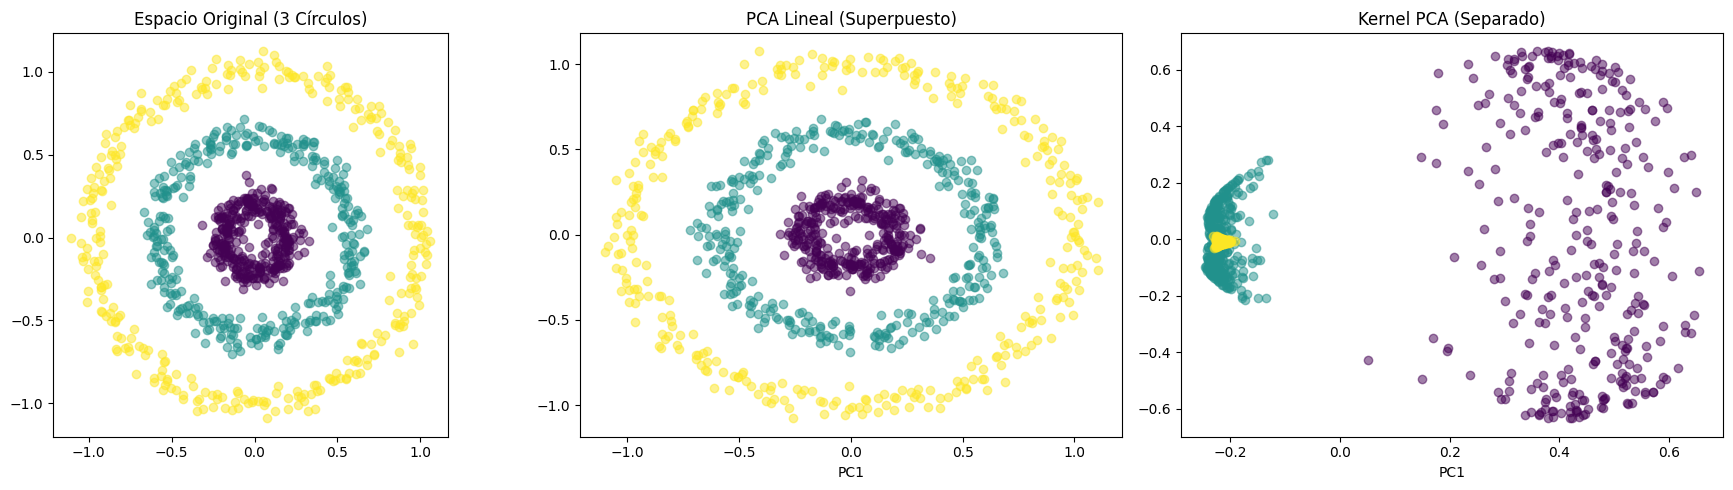

In [ ]:
# Graficamos los resultados
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
cmap = plt.colormaps['viridis'].resampled(generador.n_circles) # Mapa de colores dinámico

# Función auxiliar para pintar según clases
def plot_scatter(axis, data, labels, title):
    for i in np.unique(labels):
        axis.scatter(data[labels==i, 0], data[labels==i, 1],
                     color=cmap(i), alpha=0.5, label=f'Clase {i}')
    axis.set_title(title)
    if i == 0: axis.legend() # Solo leyenda en el primero para no ensuciar

# Original
plot_scatter(ax[0], X, y, "Espacio Original (3 Círculos)")
ax[0].set_aspect('equal')

# PCA Lineal
plot_scatter(ax[1], X_pca, y, "PCA Lineal (Superpuesto)")
ax[1].set_xlabel("PC1")

# Kernel PCA
plot_scatter(ax[2], X_kpca, y, "Kernel PCA (Separado)")
ax[2].set_xlabel("PC1")

plt.tight_layout()
plt.show()

### Definición del Pipeline y Búsqueda de Hiperparámetros
Este es el núcleo del ejercicio.
1.  **Pipeline:** Encadenamos un transformador (`KernelPCA` con kernel RBF) y un estimador (`RandomForestClassifier`). Esto evita la "fuga de datos" durante el entrenamiento.
2.  **Espacio de Búsqueda:** Definimos rangos para:
    * `kernelpca__gamma`: Controla cómo de ajustado es el kernel RBF.
    * `randomforestclassifier__n_estimators`: Número de árboles en el bosque.
3.  **RandomizedSearchCV:** Ejecutamos una búsqueda aleatoria con validación cruzada (Cross-Validation) para encontrar la mejor combinación de parámetros de forma eficiente.

In [ ]:
# Creamos el Pipeline: KernelPCA -> Random Forest
clf = make_pipeline(KernelPCA(kernel="rbf", random_state=42),
                    RandomForestClassifier(random_state=42))

# Definimos el espacio de búsqueda
param_distrib = {
    # Buscamos el mejor gamma para "desenrollar" los círculos
    "kernelpca__gamma": np.linspace(0.01, 20, 10),
    # Mantenemos 2 dimensiones
    "kernelpca__n_components": [2],
    # Buscamos los mejores parámetros para el bosque
    "randomforestclassifier__n_estimators": np.arange(50, 500, 50),
    "randomforestclassifier__max_depth": [None, 10, 20, 30]
}

# Ejecutamos RandomizedSearchCV
rnd_search = RandomizedSearchCV(clf, param_distrib, n_iter=20, cv=5, random_state=42)
rnd_search.fit(X_train, y_train)

# Vemos los mejores resultados
print("Mejores parámetros encontrados:")
print(rnd_search.best_params_)
print(f"Mejor score (validación cruzada): {rnd_search.best_score_:.4f}")

Mejores parámetros encontrados:
{'randomforestclassifier__n_estimators': np.int64(100), 'randomforestclassifier__max_depth': 10, 'kernelpca__n_components': 2, 'kernelpca__gamma': np.float64(4.452222222222222)}
Mejor score (validación cruzada): 0.9988


### Evaluación del Modelo Final
Tomamos el mejor modelo encontrado (`best_estimator_`) y lo ponemos a prueba con los datos reservados de **Test**.
Calculamos la precisión (Accuracy) para verificar si el pipeline ha logrado separar correctamente los círculos concéntricos.

Precisión en Test: 1.0000


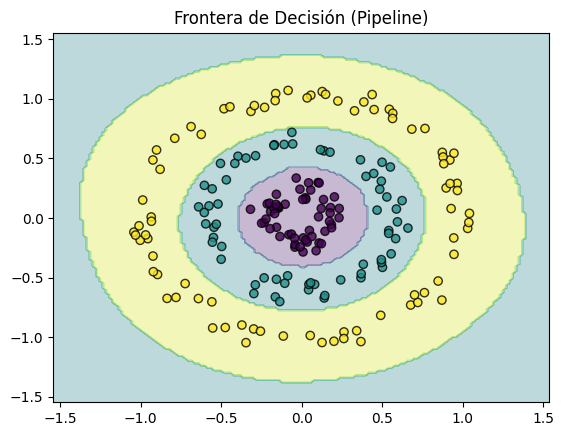

In [ ]:
# Evaluamos en el conjunto de prueba
model_final = rnd_search.best_estimator_
y_pred = model_final.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Precisión en Test: {acc:.4f}")

# Visualizamos la frontera de decisión
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', alpha=0.8)
    plt.title("Frontera de Decisión (Pipeline)")
    plt.show()

plot_decision_boundary(model_final, X_test, y_test)

### Conclusión
El uso de un **Pipeline** asegura que el preprocesamiento (KernelPCA) se ajuste solo con los datos de entrenamiento en cada pliegue de la validación cruzada. Al combinarlo con `RandomizedSearchCV`, hemos automatizado la difícil tarea de encontrar el `gamma` óptimo para desenrollar los círculos y el tamaño adecuado del `RandomForest`, obteniendo un clasificador robusto para este problema no lineal.